# 🏠 House Price Prediction

## 📌 Project Overview

This project develops a machine learning regression solution to predict residential house sale prices.

The project follows an end-to-end machine learning workflow, including data inspection, data cleaning, exploratory data analysis, feature engineering, preprocessing, model development, model evaluation, and business interpretation.

## 🎯 Objective

The objective is to build machine learning models that can estimate house sale prices based on available property characteristics.

## 🔄 Project Process Flow

```text
Business Problem
       ↓
Load Dataset
       ↓
Data Inspection
       ↓
Data Cleaning
       ↓
Missing Value Analysis
       ↓
Exploratory Data Analysis
       ↓
Feature Engineering
       ↓
Categorical Encoding
       ↓
Feature Scaling
       ↓
Train/Test Split
       ↓
Regression Model Training
       ↓
Model Evaluation
       ↓
Model Comparison
       ↓
Final Model Selection
       ↓
Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 📂 Data Loading

The house price dataset is loaded into a Pandas DataFrame for further analysis.

The initial objective is to understand:

- Number of observations
- Number of features
- Data types
- Numerical and categorical variables
- Target variable
- Missing values

The dataset will be inspected before performing any preprocessing or modelling.

In [2]:
df=pd.read_csv(r"C:\Users\tg_mu\Data Science\GitHub\House Price Prediction\train.csv")

In [3]:
df.shape

(1460, 81)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

## 2. 🔍 Initial Data Inspection

The dataset structure was examined using basic Pandas inspection methods.

The following aspects were reviewed:

- Dataset dimensions
- Column names
- Data types
- Numerical variables
- Categorical variables
- Missing values
- Potential data-quality issues

This initial inspection provides the foundation for the subsequent data-cleaning and preprocessing steps.

In [6]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 3. 🧹 Missing Value Analysis

Missing values were examined to identify incomplete or unavailable information in the house price dataset.

Missing-value analysis is an important preprocessing step because machine learning algorithms generally require appropriate treatment of missing observations before model training.

The analysis includes:

- Identifying columns containing missing values
- Measuring the number of missing observations
- Calculating missing-value percentages
- Understanding whether missingness is concentrated in specific features
- Determining an appropriate treatment strategy

### Missing Value Treatment Strategy

Depending on the nature of each feature, missing values may be handled using:

- Median imputation for numerical variables
- Mode imputation for categorical variables
- Domain-specific replacement where appropriate
- Removal of features with excessive missing values when justified

The treatment strategy should be applied using information from the training data to avoid data leakage.

In [7]:
for i in df.columns:
    if df[i].isnull().sum() > 0:
        print(i,df[i].isnull().sum())

LotFrontage 259
Alley 1369
MasVnrType 872
MasVnrArea 8
BsmtQual 37
BsmtCond 37
BsmtExposure 38
BsmtFinType1 37
BsmtFinType2 38
Electrical 1
FireplaceQu 690
GarageType 81
GarageYrBlt 81
GarageFinish 81
GarageQual 81
GarageCond 81
PoolQC 1453
Fence 1179
MiscFeature 1406


In [8]:
for i in df.columns:
    if df[i].isnull().sum() > 0 and df[i].isnull().sum() <= 81:
        print(i,df[i].isnull().sum())

MasVnrArea 8
BsmtQual 37
BsmtCond 37
BsmtExposure 38
BsmtFinType1 37
BsmtFinType2 38
Electrical 1
GarageType 81
GarageYrBlt 81
GarageFinish 81
GarageQual 81
GarageCond 81


In [9]:
# since the null values percentage is very small, drop the rows containing null values.
df.dropna(subset=['MasVnrArea','BsmtQual','BsmtCond','BsmtExposure',
                  'BsmtFinType1','BsmtFinType2','Electrical',
                  'GarageType','GarageYrBlt','GarageFinish',
                  'GarageQual','GarageCond'],axis=0,inplace=True)

In [10]:
# since the most of the values are null values,drop these columns.
df.drop(columns=['Alley','PoolQC','Fence','MiscFeature'],inplace=True)

In [11]:
for i in df.columns:
    if df[i].isnull().sum() > 0:
        print(i,df[i].isnull().sum())

LotFrontage 244
MasVnrType 763
FireplaceQu 591


In [12]:
df['MasVnrType'].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [13]:
df['FireplaceQu'].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [14]:
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [15]:
df['MasVnrType']=df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['FireplaceQu']=df['FireplaceQu'].fillna(df['FireplaceQu'].mode()[0])

In [16]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 77, dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

## 4. ✅ Data Cleaning

After identifying missing values, the dataset was cleaned and prepared for further analysis.

The cleaning process includes:

- Handling missing values
- Checking data types
- Identifying inconsistent values
- Removing unnecessary columns
- Checking for duplicate observations
- Verifying the target variable
- Preparing the dataset for exploratory analysis

The cleaned dataset is then used for Exploratory Data Analysis and subsequent machine learning preprocessing.

In [18]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,...,1338.000000,1338.000000,1338.000000,1338.000000,1338.00000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,731.228700,56.136024,70.759598,10706.294469,6.219731,5.596413,1973.029148,1985.668909,110.360239,464.234679,...,99.384903,47.782511,21.263827,3.585949,16.43423,3.010463,42.932735,6.331839,2007.805680,186761.782511
std,421.779691,41.252576,22.159883,10336.621126,1.324472,1.078124,29.563540,20.296463,185.604816,458.792420,...,127.537065,65.362562,60.843964,30.224622,58.05159,41.961337,508.056255,2.699437,1.330691,78913.847668
min,1.000000,20.000000,21.000000,1300.000000,2.000000,2.000000,1880.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,2006.000000,35311.000000
25%,366.250000,20.000000,60.000000,7744.000000,5.000000,5.000000,1956.000000,1968.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.000000,2007.000000,135000.000000
50%,730.500000,50.000000,70.759598,9600.000000,6.000000,5.000000,1976.000000,1994.500000,0.000000,413.000000,...,6.000000,28.000000,0.000000,0.000000,0.00000,0.000000,0.000000,6.000000,2008.000000,168500.000000
75%,1098.750000,70.000000,80.000000,11760.750000,7.000000,6.000000,2001.000000,2004.000000,174.000000,733.000000,...,174.500000,70.000000,0.000000,0.000000,0.00000,0.000000,0.000000,8.000000,2009.000000,220000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.00000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [19]:
df.groupby('Id')['SalePrice'].sum()

Id
1       208500
2       181500
3       223500
4       140000
5       250000
         ...  
1456    175000
1457    210000
1458    266500
1459    142125
1460    147500
Name: SalePrice, Length: 1338, dtype: int64

In [20]:
df.reset_index(drop=True,inplace=True)

In [21]:
df.drop(columns=['Id'],inplace=True)
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1334,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1335,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1336,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


## 5. 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of the house prices and the relationship between property characteristics and the target variable.

The main objective is to identify:

- Distribution of the target variable
- Important numerical features
- Important categorical features
- Relationships between property characteristics and sale price
- Potential outliers
- Skewed numerical variables
- Features that may provide useful predictive information

### Target Variable

The target variable for this regression problem is:

`SalePrice`

The analysis of `SalePrice` helps us understand the range, central tendency, spread, and distribution of house prices.

### Numerical Feature Analysis

Numerical variables are examined using:

- Descriptive statistics
- Histograms
- Box plots
- Correlation analysis
- Scatter plots

### Categorical Feature Analysis

Categorical variables are examined to understand how different property characteristics influence house prices.

Examples include:

- Overall quality
- Neighborhood
- House style
- Garage characteristics
- Basement characteristics
- Exterior characteristics

### Outlier Analysis

Outliers are investigated because extreme observations can have a significant effect on regression models.

The relationship between important numerical variables and `SalePrice` is also examined to identify potentially influential observations.

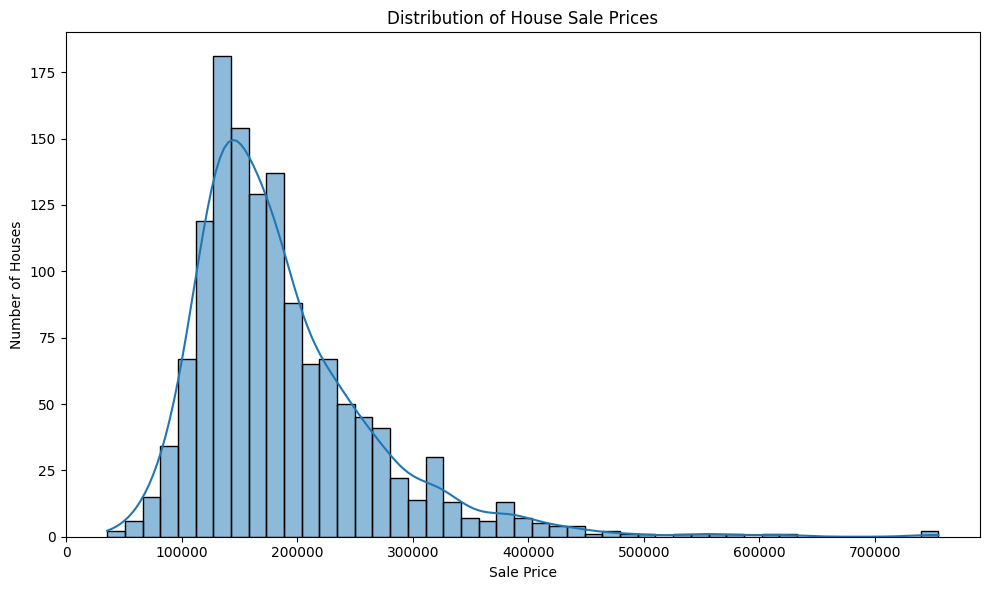

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True)

plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Number of Houses')
plt.tight_layout()

plt.savefig('visualizations/saleprice_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### SalePrice Distribution

The distribution of `SalePrice` is visualized to understand the overall pattern of house prices in the dataset.

The histogram shows the frequency of different sale-price ranges, while the KDE curve provides an estimate of the underlying distribution.

This visualization helps identify:

- The range of house prices
- The concentration of observations
- Distribution shape
- Potential skewness
- Potential extreme values

In [26]:
obj_cols=[]
for i in df.columns:
    if df[i].dtype == 'object':
        obj_cols.append(i)


In [27]:
len(obj_cols)

39

In [28]:
for i in obj_cols:
    print(i)
    print(df[i].unique())
    print()


MSZoning
['RL' 'RM' 'C (all)' 'FV' 'RH']

Street
['Pave' 'Grvl']

LotShape
['Reg' 'IR1' 'IR2' 'IR3']

LandContour
['Lvl' 'Bnk' 'Low' 'HLS']

Utilities
['AllPub' 'NoSeWa']

LotConfig
['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']

LandSlope
['Gtl' 'Mod' 'Sev']

Neighborhood
['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'Edwards' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']

Condition1
['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']

Condition2
['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']

BldgType
['1Fam' '2fmCon' 'TwnhsE' 'Duplex' 'Twnhs']

HouseStyle
['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']

RoofStyle
['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']

RoofMatl
['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTile']

Exterior1st
['VinylSd' 'MetalSd' 'Wd Sdng' '

In [29]:
df['SaleCondition'].value_counts()

SaleCondition
Normal     1104
Partial     120
Abnorml      86
Family       20
Alloca        7
AdjLand       1
Name: count, dtype: int64

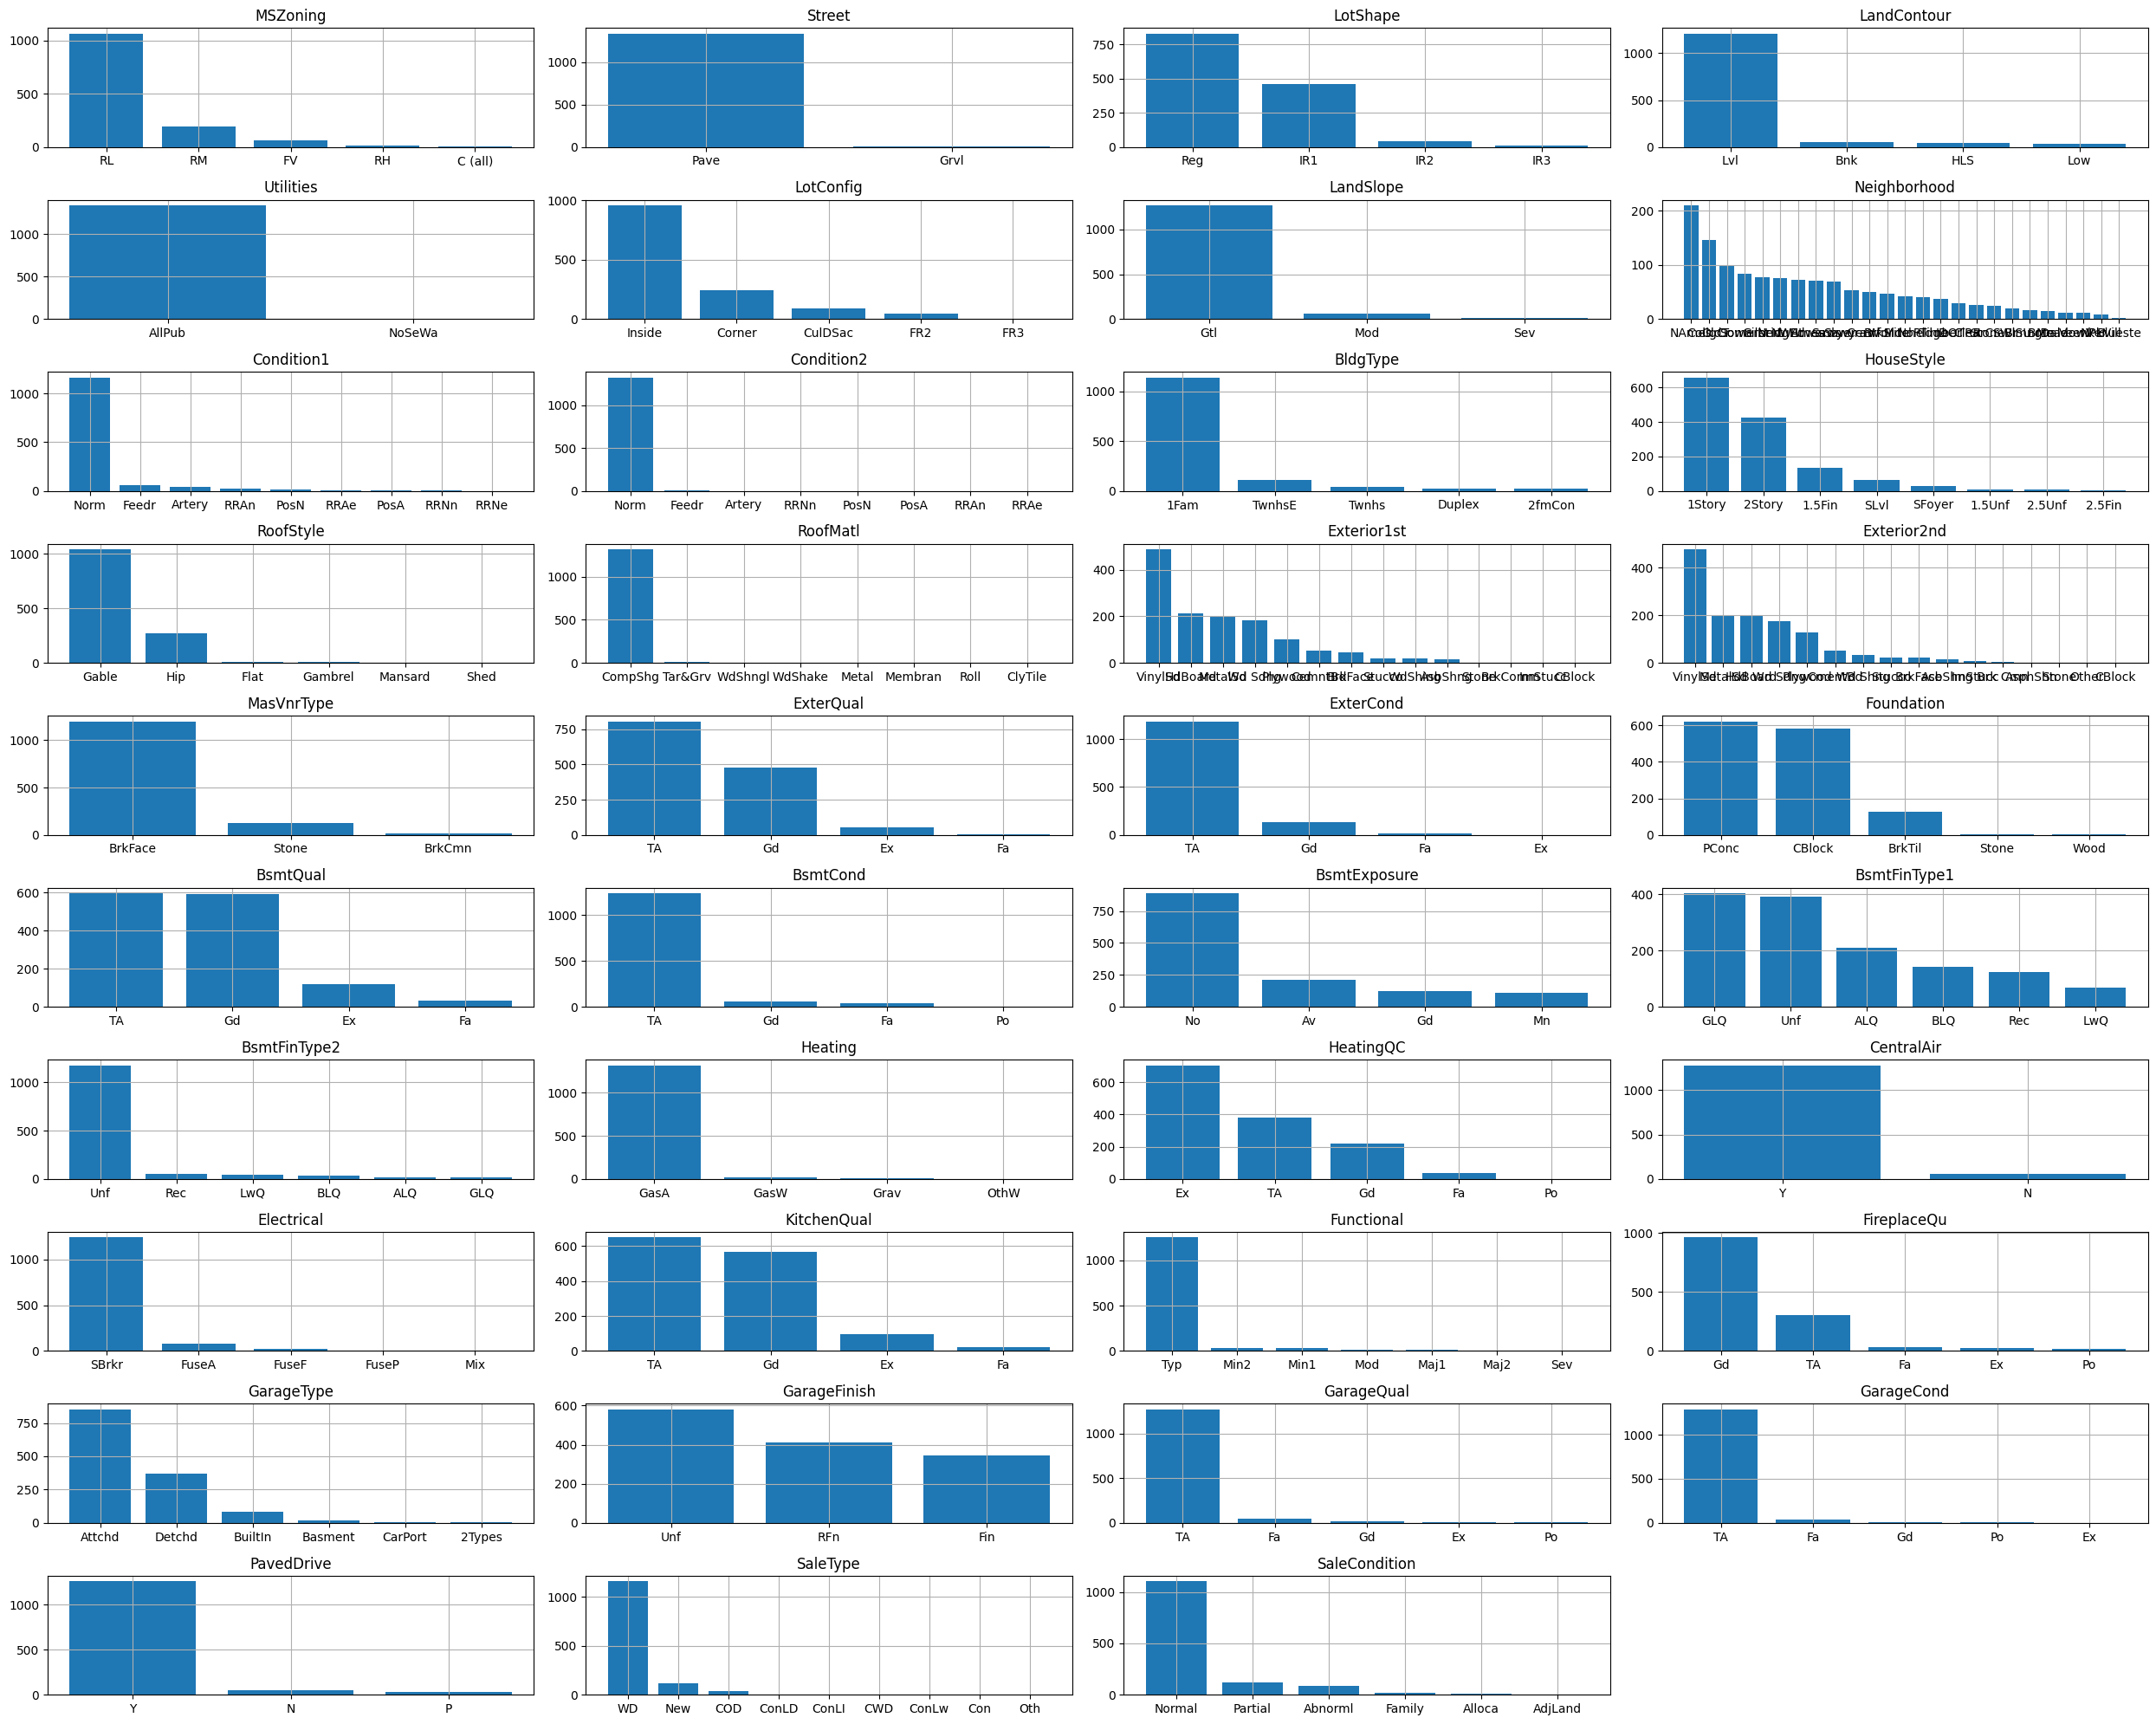

In [30]:
plt.figure(figsize=(25,20))
for index,col in enumerate(obj_cols):
    plt.subplot(10,4,index+1)
    counts=df[col].value_counts()
    plt.bar(counts.index,counts.values)
    plt.grid()
    plt.title(col)
    plt.tight_layout()
plt.show()

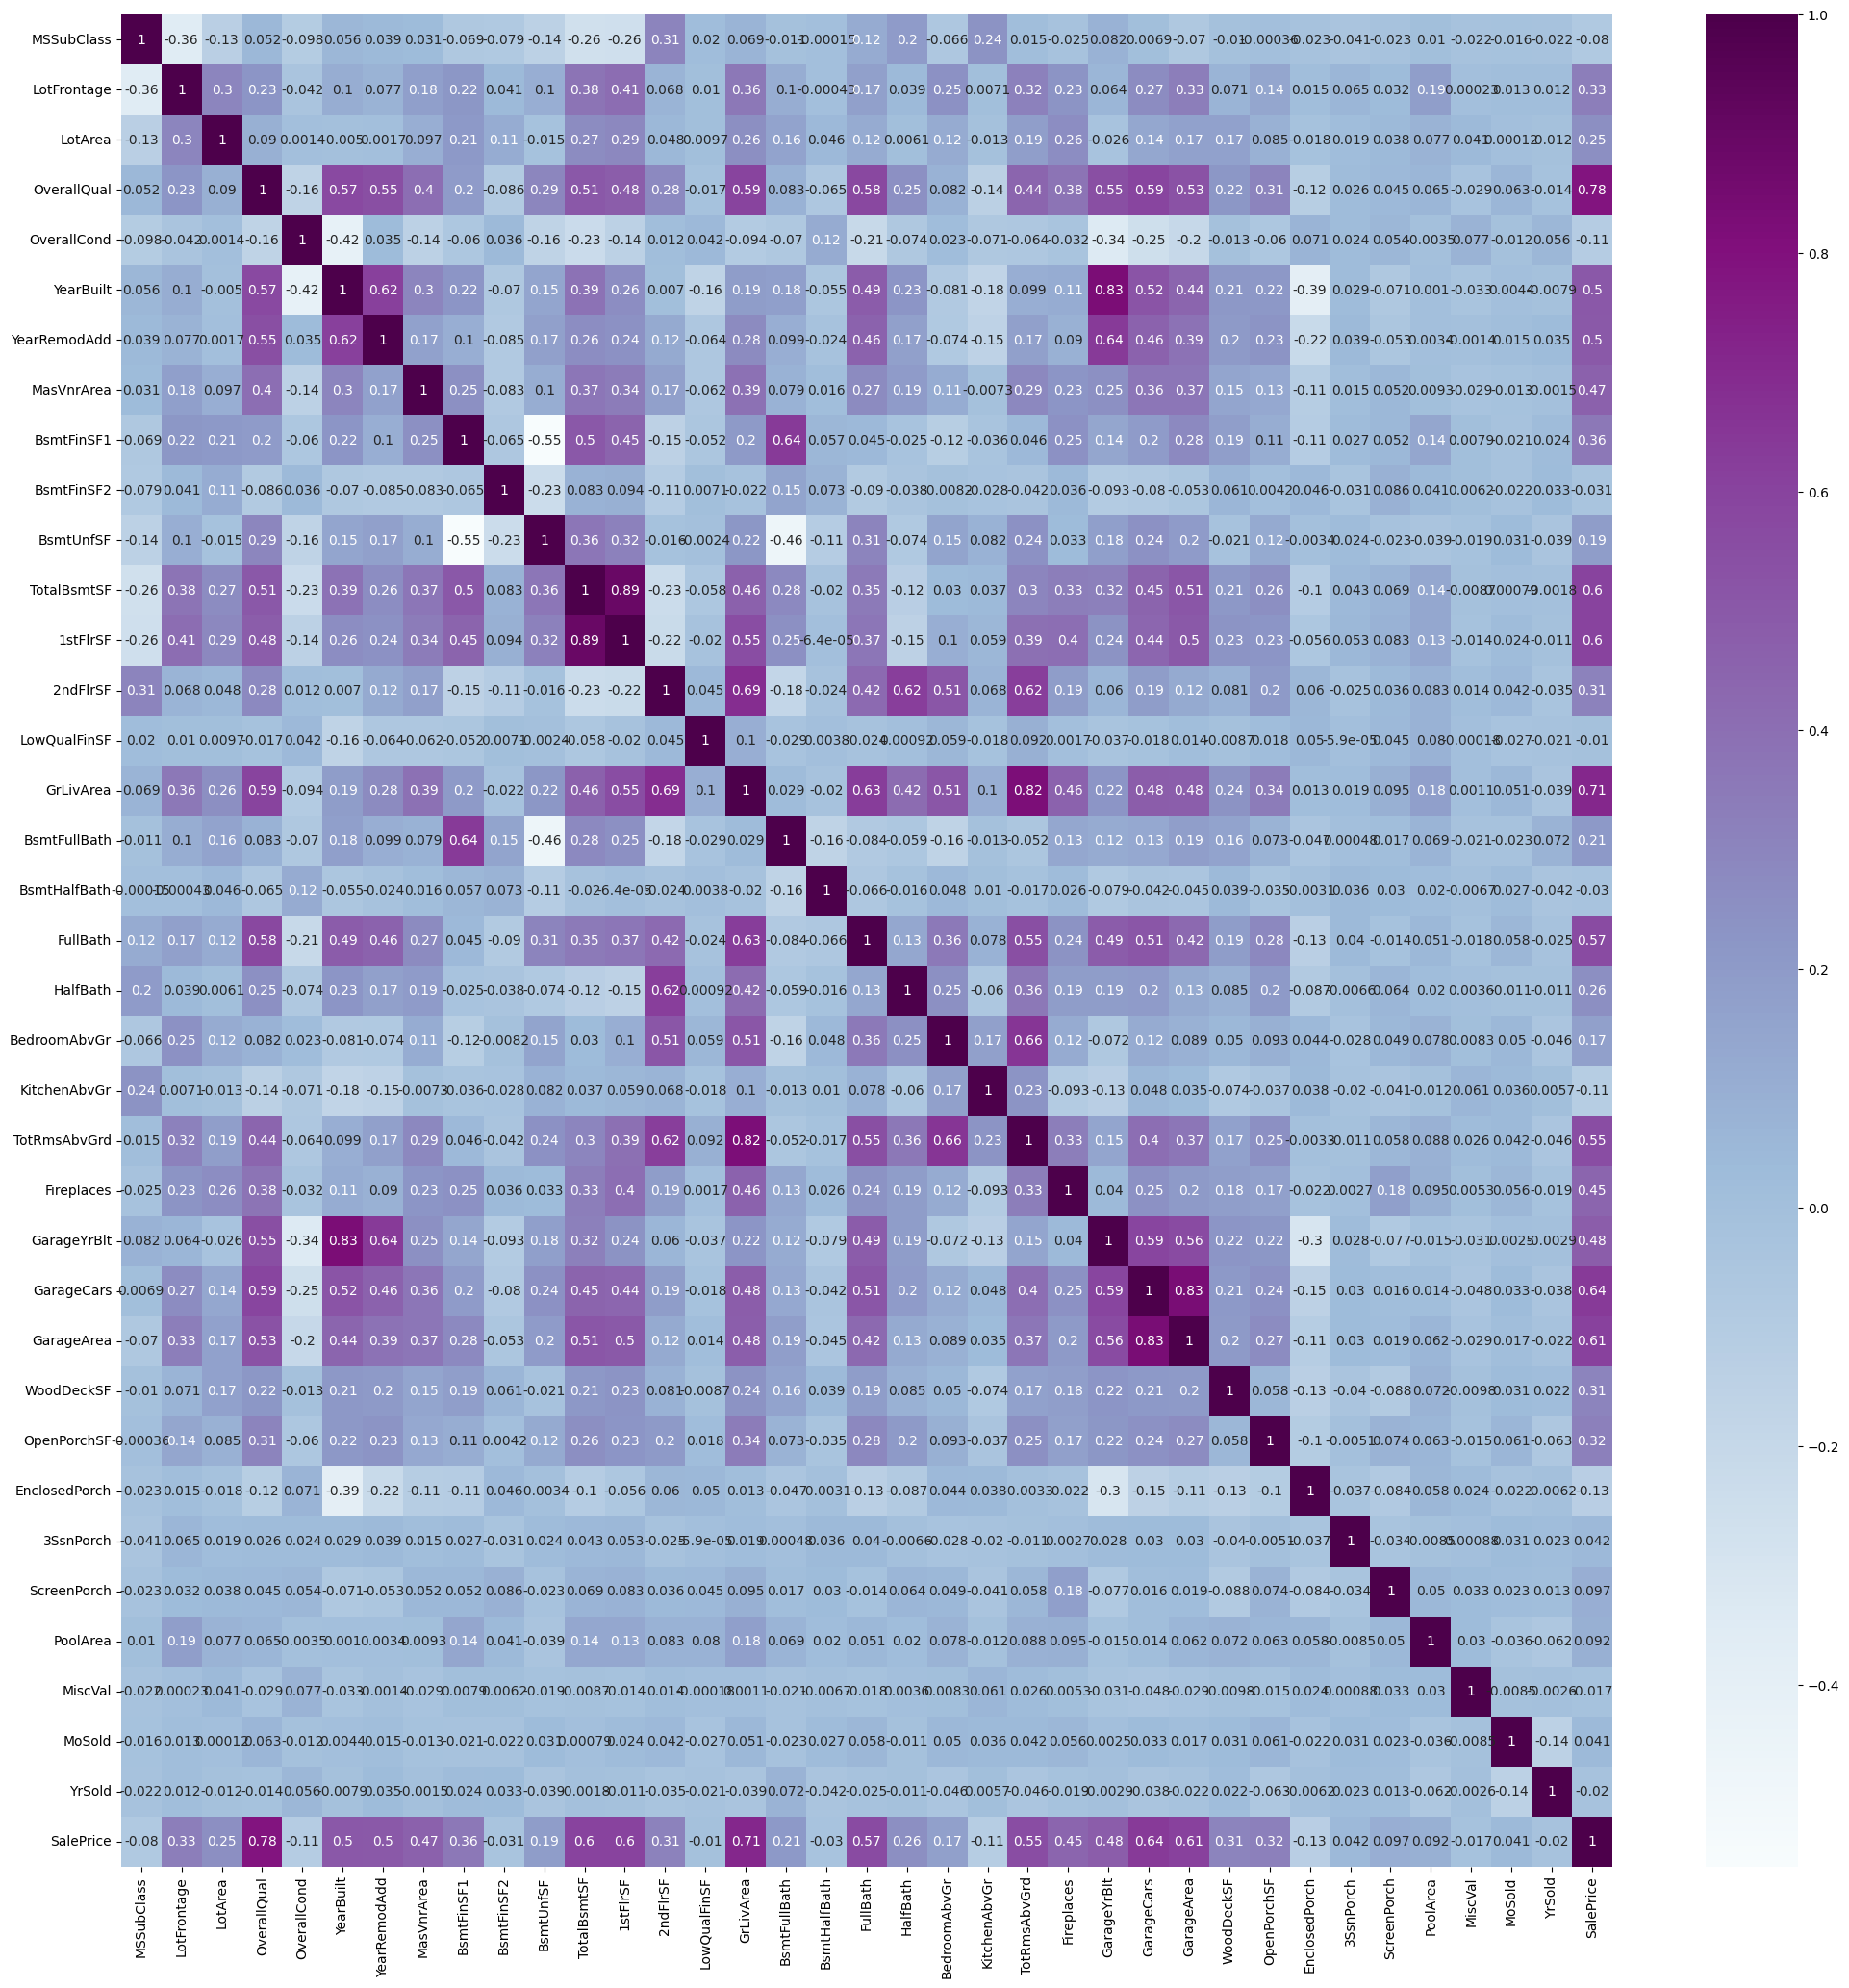

In [31]:
plt.figure(figsize=(25,25))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='BuPu')
plt.show()

In [32]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False,drop='first')

In [33]:
encoded=ohe.fit_transform(df[obj_cols])
encoded

array([[0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.]], shape=(1338, 194))

In [34]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(obj_cols),index=df.index)
encoded_df

,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1334,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1335,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [35]:
final_df=pd.concat([df.drop(columns=obj_cols),encoded_df],axis=1)
final_df

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1334,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1335,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [36]:
X=final_df.drop(columns=['SalePrice'],axis=1)
y=final_df['SalePrice']

In [37]:
X.shape

(1338, 230)

## 6. ⚙️ Feature Engineering and Data Preprocessing

After completing the exploratory analysis, the dataset is prepared for machine learning.

Feature engineering and preprocessing are performed to convert the raw property information into a format suitable for regression algorithms.

### Key preprocessing steps

- Selection of relevant predictor variables
- Separation of numerical and categorical features
- Handling of categorical variables
- Encoding categorical variables into numerical representations
- Transformation of numerical features where required
- Handling of skewed variables where appropriate
- Preparation of the final modelling dataset

### Categorical Variables

House-price datasets contain several categorical variables describing property characteristics.

These variables must be converted into numerical representations before they can be used by most machine learning algorithms.

### Numerical Variables

Numerical variables represent measurable property characteristics such as:

- Living area
- Lot area
- Number of rooms
- Garage-related measurements
- Basement-related measurements
- Year-related features

These variables are reviewed for scale, distribution, skewness, and potential outliers.

### Target Variable

The target variable is:

`SalePrice`

The objective of the regression models is to learn the relationship between the available property features and `SalePrice`.

### Data Leakage Prevention

Preprocessing steps that learn parameters from the data should be fitted using the training data and then applied to the test data.

This helps prevent information from the test set from influencing model training.

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [39]:
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)


C:\Users\tg_mu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,features,VIF
13,2ndFlrSF,inf
12,1stFlrSF,inf
10,BsmtUnfSF,inf
11,TotalBsmtSF,inf
8,BsmtFinSF1,inf
...,...,...
30,3SsnPorch,1.243158
50,LotConfig_FR3,1.239801
84,Condition1_RRNe,1.215761
218,SaleType_Con,1.210607


In [40]:
X.drop(columns=['2ndFlrSF','1stFlrSF','BsmtUnfSF','TotalBsmtSF','BsmtFinSF1'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

C:\Users\tg_mu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,features,VIF
127,Exterior2nd_CBlock,inf
180,Electrical_Mix,inf
155,BsmtCond_Po,inf
113,Exterior1st_CBlock,inf
30,YrSold,1.159432e+05
...,...,...
25,3SsnPorch,1.238852e+00
45,LotConfig_FR3,1.238759e+00
79,Condition1_RRNe,1.215648e+00
213,SaleType_Con,1.209654e+00


In [41]:
X.drop(columns=['Exterior2nd_CBlock','Electrical_Mix','BsmtCond_Po','Exterior1st_CBlock'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
30,YrSold,115757.903079
5,YearBuilt,75983.002465
19,GarageYrBlt,42677.503251
6,YearRemodAdd,37492.511203
205,GarageCond_TA,3078.582400
...,...,...
25,3SsnPorch,1.238487
45,LotConfig_FR3,1.238469
79,Condition1_RRNe,1.213615
209,SaleType_Con,1.209445


In [42]:
X.drop(columns=['YrSold'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
5,YearBuilt,46625.150438
19,GarageYrBlt,39079.885133
6,YearRemodAdd,31804.251576
204,GarageCond_TA,3078.120870
200,GarageQual_TA,2305.410994
...,...,...
44,LotConfig_FR3,1.238200
25,3SsnPorch,1.237587
78,Condition1_RRNe,1.213403
208,SaleType_Con,1.208586


In [43]:
X.drop(columns=['YearBuilt','GarageYrBlt','YearRemodAdd','GarageCond_TA','GarageQual_TA'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
100,RoofMatl_CompShg,1775.946561
140,ExterCond_TA,1220.839433
78,Condition2_Norm,1024.140027
95,RoofStyle_Gable,628.406686
31,Street_Pave,578.483313
...,...,...
22,3SsnPorch,1.236746
41,LotConfig_FR3,1.232633
75,Condition1_RRNe,1.211636
203,SaleType_Con,1.206842


In [44]:
X.drop(columns=['RoofMatl_CompShg','ExterCond_TA','Condition2_Norm','RoofStyle_Gable','Street_Pave'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
29,MSZoning_RL,214.235317
112,Exterior1st_VinylSd,185.768389
182,GarageType_Attchd,172.382188
126,Exterior2nd_VinylSd,166.064630
177,Functional_Typ,149.943773
...,...,...
40,LotConfig_FR3,1.230304
198,SaleType_Con,1.206298
74,Condition1_RRNe,1.201743
80,Condition2_RRAn,1.171581


In [45]:
X.drop(columns=['MSZoning_RL','Exterior1st_VinylSd','GarageType_Attchd','Exterior2nd_VinylSd','Functional_Typ'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
14,KitchenAbvGr,126.986592
154,BsmtFinType2_Unf,111.341425
15,TotRmsAbvGrd,110.650933
3,OverallQual,106.348682
8,GrLivArea,98.705231
...,...,...
193,SaleType_Con,1.203394
73,Condition1_RRNe,1.201035
79,Condition2_RRAn,1.168862
120,Exterior2nd_Other,1.106806


In [46]:
X.drop(columns=['KitchenAbvGr','BsmtFinType2_Unf','TotRmsAbvGrd','OverallQual','GrLivArea'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
122,MasVnrType_BrkFace,92.315804
0,MSSubClass,90.233250
192,SaleType_New,55.755474
3,OverallCond,53.954897
199,SaleCondition_Partial,53.366663
...,...,...
188,SaleType_Con,1.199246
69,Condition1_RRNe,1.198402
75,Condition2_RRAn,1.165770
116,Exterior2nd_Other,1.106348


In [47]:
X.drop(columns=['MasVnrType_BrkFace','MSSubClass','SaleType_New','OverallCond','SaleCondition_Partial'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
101,Exterior1st_MetalSd,51.329231
113,Exterior2nd_MetalSd,50.971992
11,GarageCars,50.255633
167,FireplaceQu_Gd,48.721604
154,CentralAir_Y,46.746748
...,...,...
187,SaleType_ConLI,1.185971
185,SaleType_Con,1.164781
73,Condition2_RRAn,1.154359
114,Exterior2nd_Other,1.102222


In [48]:
X.drop(columns=['Exterior1st_MetalSd','Exterior2nd_MetalSd','GarageCars','FireplaceQu_Gd','CentralAir_Y'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
131,BsmtCond_TA,45.055368
120,ExterQual_TA,40.536531
61,Condition1_Norm,38.034764
178,PavedDrive_Y,36.600063
9,BedroomAbvGr,35.699290
...,...,...
182,SaleType_ConLI,1.182304
180,SaleType_Con,1.161567
72,Condition2_RRAn,1.145311
111,Exterior2nd_Other,1.100835


In [49]:
X.drop(columns=['BsmtCond_TA','ExterQual_TA','Condition1_Norm','PavedDrive_Y','BedroomAbvGr'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
27,LandContour_Lvl,33.541583
7,FullBath,26.171266
95,Exterior1st_CemntBd,25.242057
106,Exterior2nd_CmentBd,25.078613
0,LotFrontage,24.582270
...,...,...
175,SaleType_Con,1.160756
70,Condition2_RRAn,1.144490
64,Condition1_RRNe,1.120477
109,Exterior2nd_Other,1.098712


In [50]:
X.drop(columns=['LandContour_Lvl','FullBath','Exterior1st_CemntBd','Exterior2nd_CmentBd','LotFrontage'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
175,SaleType_WD,23.274863
144,Electrical_SBrkr,21.777484
8,GarageArea,17.562780
179,SaleCondition_Normal,17.262676
121,BsmtQual_TA,16.712821
...,...,...
170,SaleType_Con,1.160084
67,Condition2_RRAn,1.143855
61,Condition1_RRNe,1.119967
104,Exterior2nd_Other,1.094261


In [51]:
X.drop(columns=['SaleType_WD','Electrical_SBrkr','GarageArea'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
120,BsmtQual_TA,16.456303
91,Exterior1st_HdBoard,16.221144
101,Exterior2nd_HdBoard,15.311786
145,KitchenQual_TA,15.150661
42,Neighborhood_NAmes,13.794408
...,...,...
167,SaleType_CWD,1.119065
168,SaleType_Con,1.117685
170,SaleType_ConLI,1.110827
103,Exterior2nd_Other,1.091896


In [52]:
X.drop(columns=['BsmtQual_TA','Exterior1st_HdBoard','Exterior2nd_HdBoard','KitchenQual_TA'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
113,Foundation_PConc,12.584571
42,Neighborhood_NAmes,11.600379
112,Foundation_CBlock,11.103332
73,HouseStyle_1Story,9.198810
95,Exterior1st_Wd Sdng,9.048625
...,...,...
163,SaleType_CWD,1.114613
60,Condition1_RRNe,1.112690
166,SaleType_ConLI,1.106795
101,Exterior2nd_Other,1.085876


In [53]:
X.drop(columns=['Foundation_PConc','Neighborhood_NAmes','Foundation_CBlock'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
94,Exterior1st_Wd Sdng,9.018537
104,Exterior2nd_Wd Sdng,8.799521
169,SaleCondition_Normal,7.890350
72,HouseStyle_1Story,7.542493
118,BsmtExposure_No,7.219181
...,...,...
160,SaleType_CWD,1.112490
59,Condition1_RRNe,1.110044
163,SaleType_ConLI,1.104195
100,Exterior2nd_Other,1.085160


In [54]:
X.drop(columns=['Exterior1st_Wd Sdng'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
168,SaleCondition_Normal,7.876593
72,HouseStyle_1Story,7.541914
117,BsmtExposure_No,7.212206
15,MoSold,7.020524
75,HouseStyle_2Story,6.448599
...,...,...
159,SaleType_CWD,1.112432
59,Condition1_RRNe,1.109957
162,SaleType_ConLI,1.103496
99,Exterior2nd_Other,1.085142


In [55]:
X.drop(columns=['SaleCondition_Normal'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
72,HouseStyle_1Story,7.406173
117,BsmtExposure_No,7.044139
15,MoSold,7.017912
75,HouseStyle_2Story,6.340245
50,Neighborhood_Somerst,6.145505
...,...,...
159,SaleType_CWD,1.111448
59,Condition1_RRNe,1.109463
162,SaleType_ConLI,1.103487
99,Exterior2nd_Other,1.081002


In [56]:
X.drop(columns=['HouseStyle_1Story','BsmtExposure_No','MoSold'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
49,Neighborhood_Somerst,6.111700
0,LotArea,5.607300
148,GarageFinish_Unf,5.477590
27,LotConfig_Inside,5.219305
15,MSZoning_FV,4.999367
...,...,...
156,SaleType_CWD,1.110835
58,Condition1_RRNe,1.106706
159,SaleType_ConLI,1.095915
97,Exterior2nd_Other,1.080662


In [57]:
X.drop(columns=['Neighborhood_Somerst'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
0,LotArea,5.592032
147,GarageFinish_Unf,5.473400
27,LotConfig_Inside,5.203353
17,MSZoning_RM,4.404779
110,BsmtQual_Gd,4.381817
...,...,...
155,SaleType_CWD,1.110370
57,Condition1_RRNe,1.106635
158,SaleType_ConLI,1.095831
96,Exterior2nd_Other,1.080646


In [58]:
X.drop(columns=['LotArea'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
146,GarageFinish_Unf,5.445850
26,LotConfig_Inside,5.196659
16,MSZoning_RM,4.403514
109,BsmtQual_Gd,4.369458
44,Neighborhood_OldTown,4.351758
...,...,...
154,SaleType_CWD,1.110368
56,Condition1_RRNe,1.106629
157,SaleType_ConLI,1.095445
95,Exterior2nd_Other,1.080646


In [59]:
X.drop(columns=['GarageFinish_Unf'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
26,LotConfig_Inside,5.101218
16,MSZoning_RM,4.398400
109,BsmtQual_Gd,4.369436
114,BsmtFinType1_GLQ,4.322819
44,Neighborhood_OldTown,4.294626
...,...,...
153,SaleType_CWD,1.109976
56,Condition1_RRNe,1.106563
156,SaleType_ConLI,1.093423
95,Exterior2nd_Other,1.080574


In [60]:
X.drop(columns=['LotConfig_Inside'],axis=1,inplace=True)
vif=pd.DataFrame()
vif['features']=X.columns
vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif.sort_values(by='VIF',ascending=False)

,features,VIF
16,MSZoning_RM,4.398318
108,BsmtQual_Gd,4.355206
43,Neighborhood_OldTown,4.289157
6,Fireplaces,4.252295
113,BsmtFinType1_GLQ,4.177873
...,...,...
152,SaleType_CWD,1.109916
55,Condition1_RRNe,1.105534
155,SaleType_ConLI,1.090428
94,Exterior2nd_Other,1.080117


## 7. ✂️ Train/Test Split

The prepared dataset is divided into training and testing subsets.

```text
Full Dataset
     ↓
Train/Test Split
     ↓
┌───────────────┬───────────────┐
│ Training Set  │   Test Set    │
│               │               │
│ Model         │ Final         │
│ Development  │ Evaluation    │
└───────────────┴───────────────┘

In [61]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [90]:
feature_names = X.columns.tolist()

print("Number of feature names:", len(feature_names))
print("Number of feature importances:", len(best_model.feature_importances_))

Number of feature names: 161
Number of feature importances: 161


In [62]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1070, 161)
(1070,)
(268, 161)
(268,)


In [63]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [64]:
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [66]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=params,
    n_iter=20,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

In [67]:
models={'LinearRegression':LinearRegression(),
        'RandomForestRegressor':RandomForestRegressor(n_estimators=500,
                                                        max_depth=None,
                                                        min_samples_split=2,
                                                        min_samples_leaf=1,
                                                        random_state=42),
        'GradientBoostingRegressor':GradientBoostingRegressor(),
        'XGBRegressor':XGBRegressor(n_estimators=700,
                                learning_rate=0.05,
                                max_depth=4,
                                min_child_weight=3,
                                subsample=0.8,
                                colsample_bytree=0.7,
                                reg_alpha=0,
                                reg_lambda=1,
                                random_state=42)
}

In [68]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score


## 8. 🤖 Regression Model Development

The prepared training data is used to develop machine learning regression models for predicting house sale prices.

Multiple regression algorithms are evaluated rather than relying on a single model.

The purpose of comparing multiple models is to determine which algorithm provides the best predictive performance on unseen house-price data.

### Model Development Process

```text
Training Data
      ↓
Regression Models
      ↓
Generate Predictions
      ↓
Compare Predictions with Actual Prices
      ↓
Calculate Evaluation Metrics
      ↓
Compare Models
      ↓
Select Final Model

In [69]:
results={}

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    results[name]=y_pred

    print(name)
    print(f'mae:',mean_absolute_error(y_test,y_pred))
    print(f'rmse:',root_mean_squared_error(y_test,y_pred))
    print(f'r2_score:',r2_score(y_test,y_pred))
    print()



LinearRegression
mae: 32553.812181859867
rmse: 42467.736866935484
r2_score: 0.57853143353107

RandomForestRegressor
mae: 24867.92311433902
rmse: 36543.71588991752
r2_score: 0.6879153802654812

GradientBoostingRegressor
mae: 26491.26148630033
rmse: 37675.588184841574
r2_score: 0.6682835286846772

XGBRegressor
mae: 23752.68359375
rmse: 34632.39453125
r2_score: 0.7197071313858032



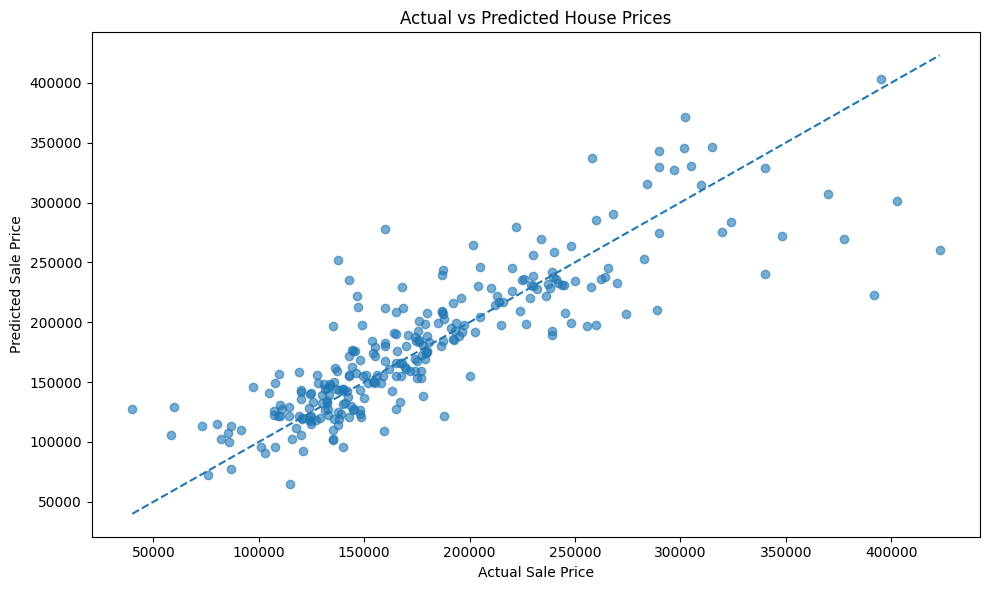

In [70]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Ideal prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')

plt.tight_layout()

plt.savefig(
    'visualizations/actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Actual vs Predicted SalePrice

The actual versus predicted visualization evaluates how closely the final XGBoost model's predictions match the actual house sale prices.

The dashed diagonal line represents perfect predictions.

Points closer to the diagonal indicate predictions that are closer to the actual sale prices.

This visualization provides an intuitive assessment of the final regression model's predictive performance.

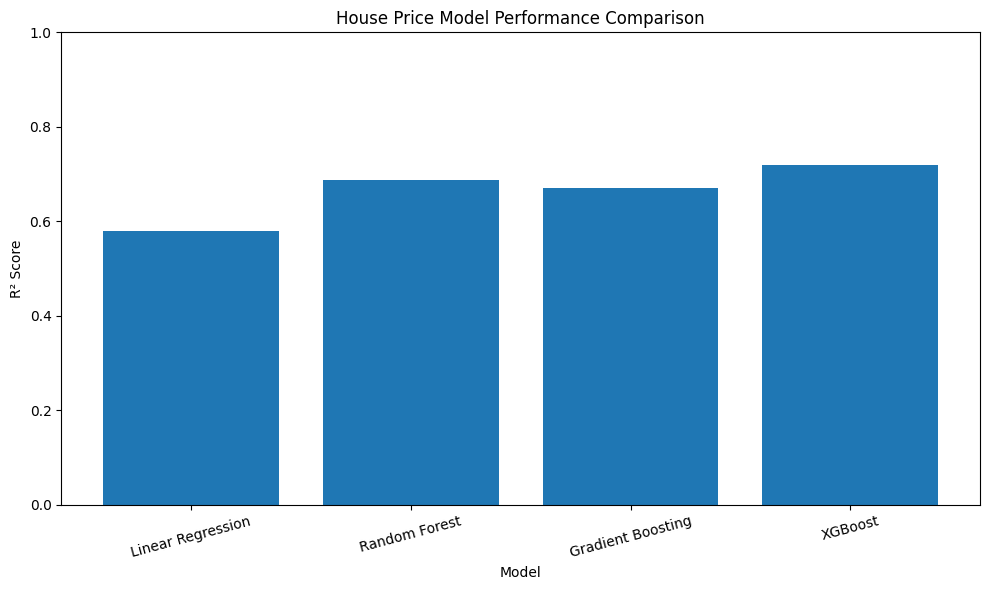

In [74]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'R2 Score': [
        0.5785,
        0.6879,
        0.6699,
        0.7197
    ]
})

plt.figure(figsize=(10, 6))

plt.bar(
    model_results['Model'],
    model_results['R2 Score']
)

plt.title('House Price Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'visualizations/model_performance_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Model Performance Comparison

The R² scores of the four regression models are compared to identify the model with the strongest predictive performance.

The comparison shows that XGBoost achieved the highest test-set R² score of **0.7197**, followed by Random Forest, Gradient Boosting, and Linear Regression.

XGBoost was therefore selected as the final model for the house-price prediction project.

## 9. 📈 Model Evaluation and Comparison

Four regression models were trained and evaluated using the test dataset:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

### Evaluation Metrics

**MAE — Mean Absolute Error**

Measures the average absolute difference between the actual and predicted house prices.

Lower MAE indicates smaller average prediction errors.

**RMSE — Root Mean Squared Error**

Measures the square root of the average squared prediction error.

RMSE gives greater weight to larger prediction errors.

Lower RMSE indicates better predictive performance.

**R² Score**

Measures the proportion of variation in the target variable explained by the model.

Higher R² indicates better explanatory performance.

## 🏆 Model Comparison

The test-set performance of the four regression models is shown below.

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 32,553.81 | 42,467.74 | 0.5785 |
| Random Forest Regressor | 24,867.92 | 36,543.72 | 0.6879 |
| Gradient Boosting Regressor | 26,419.09 | 37,582.22 | 0.6699 |
| **XGBoost Regressor** | **23,752.68** | **34,632.39** | **0.7197** |

### Result

XGBoost Regressor achieved the best performance on the test set:

- **MAE:** 23,752.68
- **RMSE:** 34,632.39
- **R² Score:** 0.7197

It achieved the lowest MAE and RMSE and the highest R² score among the four evaluated models.

## ⚙️ XGBoost Hyperparameter Tuning

XGBoost hyperparameters were optimized using `RandomizedSearchCV`.

The search evaluated combinations of:

- Number of estimators
- Maximum tree depth
- Learning rate
- Subsample ratio
- Column sampling ratio

The hyperparameter search used:

- 20 randomized parameter combinations
- 5-fold cross-validation
- R² as the optimization metric
- `random_state=42`

The best XGBoost estimator from the search was stored as `best_model`.

## 🔎 Feature Importance

Feature importance from the selected XGBoost model is examined to understand which predictors contribute most strongly to the model's house-price predictions.

The feature-importance analysis helps provide an interpretable view of the variables that the model considers useful when estimating house prices.

The top 20 features are visualized below.

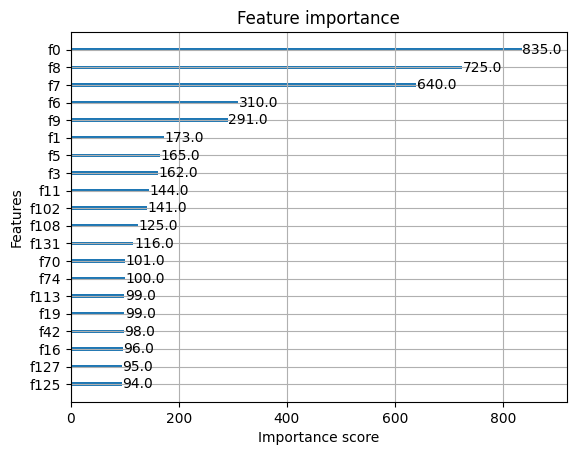

In [76]:
from xgboost import plot_importance

plot_importance(best_model, max_num_features=20)
plt.show()

In [91]:
feature_names = X.columns.tolist()

print("Number of feature names:", len(feature_names))
print("Number of feature importances:", len(best_model.feature_importances_))

Number of feature names: 161
Number of feature importances: 161


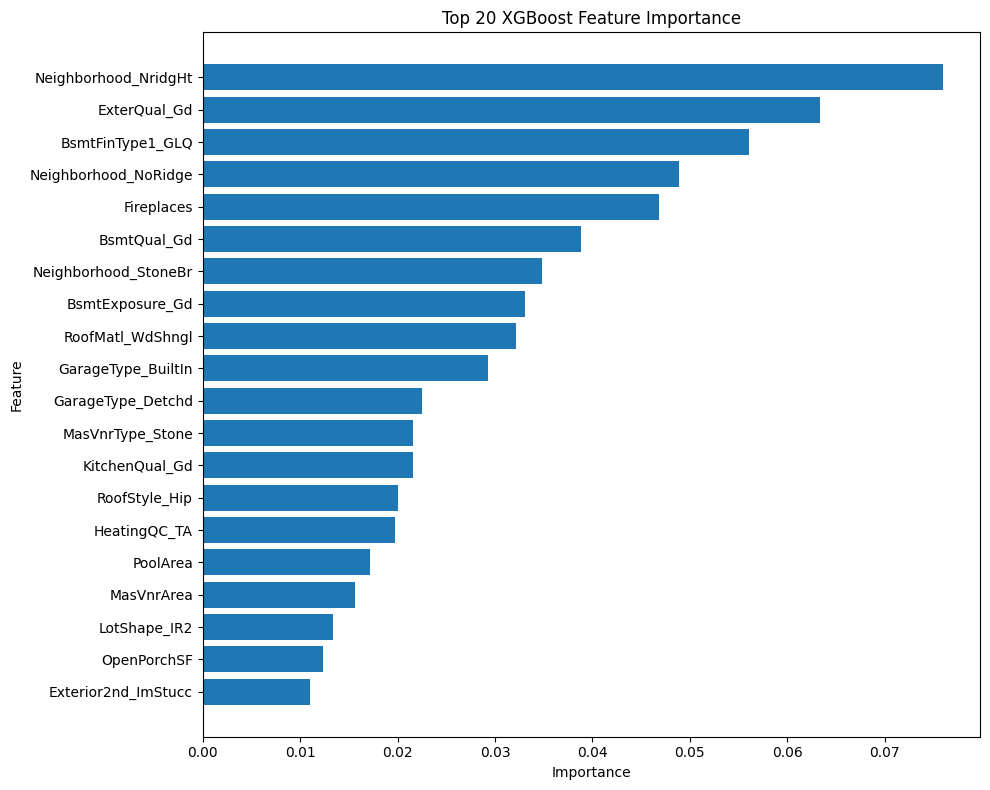

In [92]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values('Importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1]
)

plt.title('Top 20 XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()

plt.savefig(
    'visualizations/xgboost_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [93]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.77023596 0.73315257 0.75502574 0.80379736 0.66652536]
0.7457473993301391


## 🔄 Cross-Validation

Five-fold cross-validation was performed on the selected XGBoost model to assess its performance across different subsets of the dataset.

The resulting R² scores were:

- Fold 1: 0.7702
- Fold 2: 0.7332
- Fold 3: 0.7550
- Fold 4: 0.8038
- Fold 5: 0.6665

### Mean Cross-Validation R²

**0.7457**

The mean cross-validation R² provides an additional estimate of the model's generalization performance across different data splits.

In [94]:
import joblib

joblib.dump(best_model, "house_price_xgboost.pkl")

['house_price_xgboost.pkl']

## 10. 🏆 Final Model Selection

Based on the test-set evaluation, **XGBoost Regressor** was selected as the final model.

The model achieved:

- **MAE:** 23,752.68
- **RMSE:** 34,632.39
- **R² Score:** 0.7197

XGBoost produced the lowest MAE and RMSE and the highest R² score among the four evaluated regression models.

Therefore, XGBoost provides the strongest predictive performance for this house-price prediction problem.

### Cross-Validation Result

The selected XGBoost model was further evaluated using 5-fold cross-validation.

The mean cross-validation R² score was:

**0.7457**

This provides additional evidence that the model can generalize reasonably well across different subsets of the data.

---

## 11. 💼 Business Interpretation

The final model can be used as a decision-support tool for estimating residential property prices.

Potential applications include:

- Supporting property valuation
- Estimating expected selling prices
- Comparing property characteristics
- Supporting real-estate investment analysis
- Identifying important factors influencing house prices
- Assisting pricing decisions

The model should be used together with domain knowledge and current market conditions rather than as the sole basis for property valuation.

---

## 12. 🔎 Feature Importance

The XGBoost feature-importance analysis provides insight into which property characteristics contribute most to the model's predictions.

Understanding feature importance helps bridge the gap between machine learning predictions and business interpretation.

The top 20 features are visualized in the notebook.

---

## 13. 📌 Conclusion

This project demonstrates a complete machine learning regression workflow for house-price prediction.

The workflow included:

- Data inspection
- Data cleaning
- Missing-value treatment
- Exploratory Data Analysis
- Feature engineering
- Data preprocessing
- Train/test splitting
- Regression model development
- Model evaluation
- Model comparison
- XGBoost hyperparameter tuning
- Cross-validation
- Feature-importance analysis

Four regression algorithms were compared:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor
4. XGBoost Regressor

Among these models, **XGBoost Regressor achieved the best test-set performance** with an R² score of **0.7197** and an RMSE of **34,632.39**.

The tuned model also achieved a mean 5-fold cross-validation R² score of **0.7457**.

Overall, the project demonstrates how machine learning can be applied to estimate house prices while combining predictive modelling with model evaluation and business interpretation.